In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Paths
data_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

train_path = os.path.join(data_path, "train")
val_path = os.path.join(data_path, "val")
test_path = os.path.join(data_path, "test")

# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

# Load datasets
train_data = datasets.ImageFolder(train_path, transform=train_transforms)
val_data = datasets.ImageFolder(val_path, transform=val_transforms)
test_data = datasets.ImageFolder(test_path, transform=val_transforms)

# DataLoaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [2]:
import os
os.makedirs("/kaggle/working/results/transfer", exist_ok=True)

In [3]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

# Freeze layers
for param in model.parameters():
    param.requires_grad = False

# Modify final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 133MB/s] 


Classes: ['NORMAL', 'PNEUMONIA']


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1
Train Loss: 0.4438
Val Accuracy: 0.8125
------------------------------
Epoch 2
Train Loss: 0.2909
Val Accuracy: 0.8750
------------------------------
Epoch 3
Train Loss: 0.2535
Val Accuracy: 0.9375
------------------------------
Epoch 4
Train Loss: 0.2344
Val Accuracy: 0.9375
------------------------------
Epoch 5
Train Loss: 0.2448
Val Accuracy: 0.9375
------------------------------


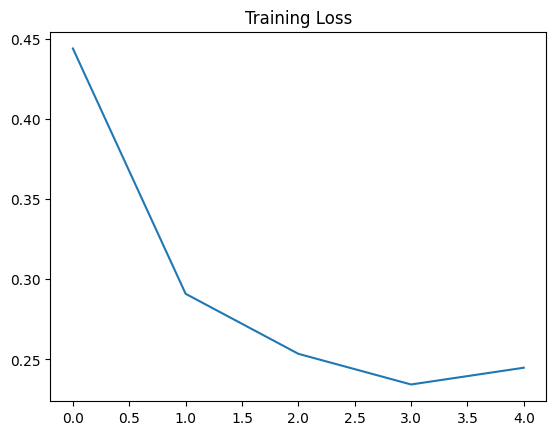

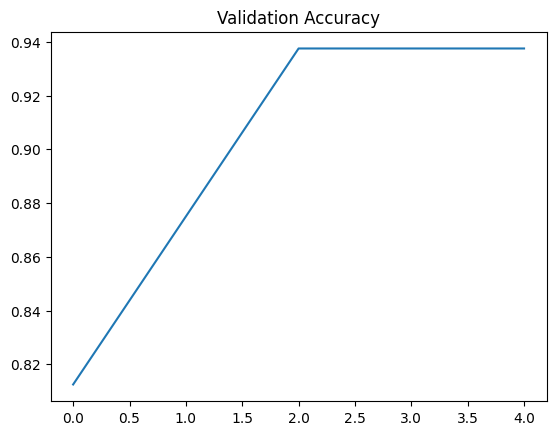

FINAL TEST ACCURACY: 0.9006410256410257


In [4]:
# =========================
# 1. IMPORTS
# =========================
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# 2. PATHS
# =========================
data_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

train_path = os.path.join(data_path, "train")
val_path = os.path.join(data_path, "val")
test_path = os.path.join(data_path, "test")

# =========================
# 3. TRANSFORMS
# =========================
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# =========================
# 4. DATA
# =========================
train_data = datasets.ImageFolder(train_path, transform=train_transforms)
val_data = datasets.ImageFolder(val_path, transform=val_transforms)
test_data = datasets.ImageFolder(test_path, transform=val_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print("Classes:", train_data.classes)

# =========================
# 5. CLASS WEIGHTS
# =========================
labels = train_data.targets
class_counts = Counter(labels)

total = sum(class_counts.values())
weights = [total/class_counts[i] for i in range(len(class_counts))]
weights = torch.tensor(weights).to(device)

# =========================
# 6. RESULT FOLDER
# =========================
os.makedirs("/kaggle/working/results/no_finetune_best", exist_ok=True)

# =========================
# 7. MODEL (NO FINE-TUNING)
# =========================
model = models.resnet18(pretrained=True)

# Freeze ALL layers (IMPORTANT)
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

# =========================
# 8. LOSS + OPTIMIZER
# =========================
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.AdamW(model.parameters(), lr=0.0003, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# =========================
# 9. TRAINING
# =========================
epochs = 5

train_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # Validation
    model.eval()
    correct = 0
    total_val = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            correct += (preds == labels).sum().item()
            total_val += labels.size(0)
    
    val_acc = correct / total_val
    val_accuracies.append(val_acc)

    scheduler.step()

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {epoch_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")
    print("-"*30)

# =========================
# 10. SAVE MODEL + GRAPHS
# =========================
torch.save(model.state_dict(), "/kaggle/working/results/no_finetune_best/model.pth")

plt.plot(train_losses)
plt.title("Training Loss")
plt.savefig("/kaggle/working/results/no_finetune_best/loss.png")
plt.show()

plt.plot(val_accuracies)
plt.title("Validation Accuracy")
plt.savefig("/kaggle/working/results/no_finetune_best/val_accuracy.png")
plt.show()

# =========================
# 11. FINAL TEST ACCURACY
# =========================
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)

print("FINAL TEST ACCURACY:", acc)

# Save accuracy
with open("/kaggle/working/results/no_finetune_best/accuracy.txt", "w") as f:
    f.write(f"Accuracy: {acc}")